In [ ]:
# Install required libraries
!pip install sentence-transformers seaborn matplotlib

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took three wickets in one over",
    "Cricket is played between two teams of eleven players",
    "India won the Test match by an innings and 50 runs.",

    # Cooking
    "Cooking requires fresh ingredients and proper timing",
    "The chef prepared a delicious pasta dish",
    "Baking a cake needs accurate measurements",

    # Cybersecurity
    "Cybersecurity protects systems from digital attacks",
    "Strong passwords help secure online accounts",
    "Hackers try to exploit system vulnerabilities",
]

In [ ]:
# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode all sentences
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

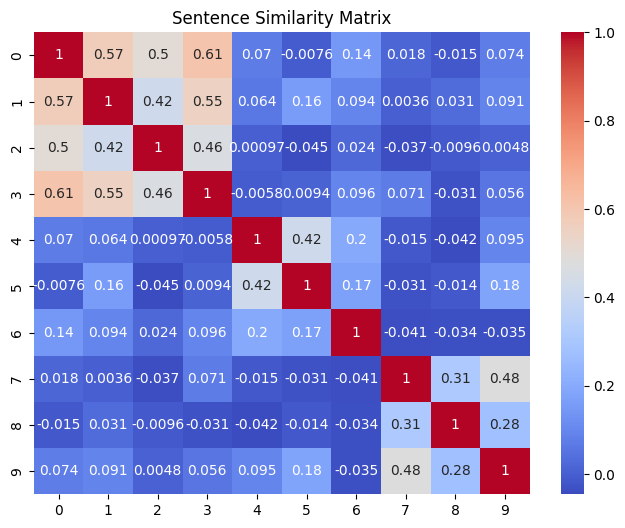

In [ ]:
# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)  # shape: (10, 10)


# Plot the heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Sentence Similarity Matrix")
plt.show()

In [ ]:
# ── Query sentence ────────────────────────────────────────────────────────────
query = "The bowler took three wickets in one over"

# Encode query
query_embedding = model.encode([query])

# Compute cosine similarity between query and all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Sort by similarity

top_indices = np.argsort(query_similarities)[-3:][::-1]   # top 3 (1 will be same sentence)

for i in top_indices:
    print(f"Sentence: {sentences[i]}")
    print(f"Similarity: {query_similarities[i]:.4f}")
    print()

Sentence: The bowler took three wickets in one over
Similarity: 1.0000

Sentence: The batsman scored a century in the match
Similarity: 0.5682

Sentence: India won the Test match by an innings and 50 runs.
Similarity: 0.5491

